# Domain alignment comparison
Side-by-side grid of domain A (real, MediaPipe-aligned) vs domain B (anime, center-cropped).
Goal: visually confirm both domains place faces at the same canonical position.

In [1]:
import sys

sys.path.insert(0, "..")

import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from kaoanime.utils.align import AlignFaceProcessor
from kaoanime.utils.transforms import get_transforms

In [2]:
# ── Configure paths ───────────────────────────────────────────────────────────
ROOT_A = Path("/beta/home/madorskii/datasets/CelebA/img_align_celeba/img_align_celeba")
ROOT_B = Path("/beta/home/madorskii/datasets/alignedanimefaces/safebooru_jpeg")

IMAGE_SIZE = 128
N_COLS = 8  # images per domain per row
SEED = 42

In [3]:
def collect(root: Path, n: int, seed: int = 42) -> list[Path]:
    exts = {".jpg", ".jpeg", ".png"}
    files = [p for p in root.iterdir() if p.suffix.lower() in exts]
    rng = random.Random(seed)
    return rng.sample(files, min(n, len(files)))


def center_crop(img: np.ndarray, size: int) -> np.ndarray:
    h, w = img.shape[:2]
    s = min(h, w)
    y0, x0 = (h - s) // 2, (w - s) // 2
    return cv2.resize(
        img[y0 : y0 + s, x0 : x0 + s], (size, size), interpolation=cv2.INTER_AREA
    )


def tensor_to_rgb(t) -> np.ndarray:
    """[-1,1] CHW tensor → HWC uint8."""
    return (t.clamp(-1, 1).add(1).div(2).permute(1, 2, 0).numpy() * 255).astype(
        np.uint8
    )

In [4]:
transform = get_transforms("train", image_size=IMAGE_SIZE)
processor = AlignFaceProcessor()

files_a = collect(ROOT_A, N_COLS, SEED)
files_b = collect(ROOT_B, N_COLS, SEED)


def load_a(path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Returns (raw_128, aligned_128) for a domain-A image."""
    raw = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    raw_crop = center_crop(raw, IMAGE_SIZE)
    aligned = processor.align(raw, IMAGE_SIZE)
    return raw_crop, (aligned if aligned is not None else raw_crop)


def load_b(path: Path) -> np.ndarray:
    """Returns center-cropped domain-B image."""
    raw = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    return center_crop(raw, IMAGE_SIZE)

W0000 00:00:1778612272.853738 4087849 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1778612272.904427 4087849 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1778612272.968753 4087900 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 570.172.08), renderer: NVIDIA A100 80GB PCIe/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1778612273.000903 4087859 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778612273.033140 4087865 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [5]:
raws_a, aligned_a = zip(*[load_a(p) for p in files_a])
crops_b = [load_b(p) for p in files_b]

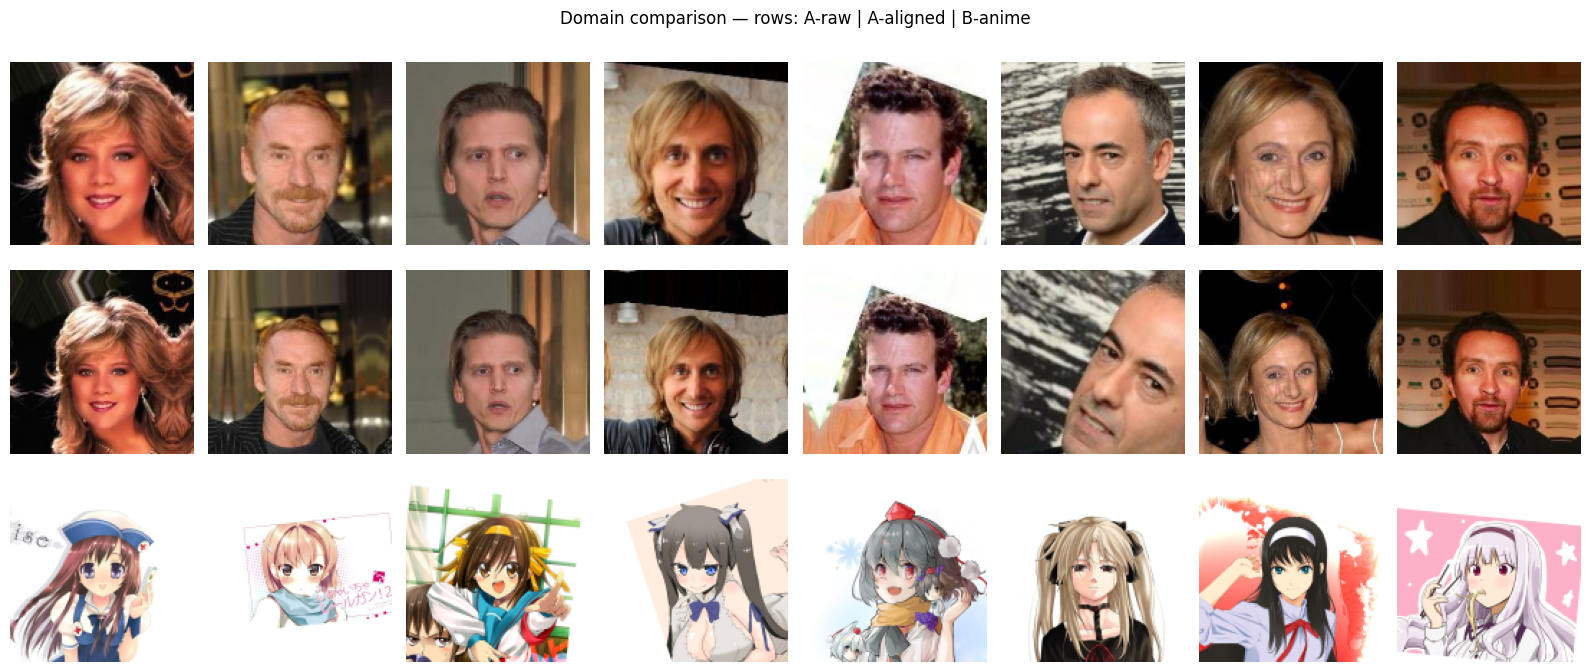

In [6]:
def show_row(images: list[np.ndarray], title: str, ax_row):
    ax_row[0].set_ylabel(title, fontsize=10, rotation=0, labelpad=80, va="center")
    for ax, img in zip(ax_row, images):
        ax.imshow(img)
        ax.axis("off")


fig, axes = plt.subplots(3, N_COLS, figsize=(N_COLS * 2, 7))
show_row(list(raws_a), "A  raw\n(center-crop)", axes[0])
show_row(list(aligned_a), "A  aligned\n(MediaPipe)", axes[1])
show_row(list(crops_b), "B  anime\n(center-crop)", axes[2])

fig.suptitle("Domain comparison — rows: A-raw | A-aligned | B-anime", fontsize=12)
plt.tight_layout()
plt.show()

## With full training transform (augmentation preview)
Shows how images look after the complete pipeline the model actually sees.

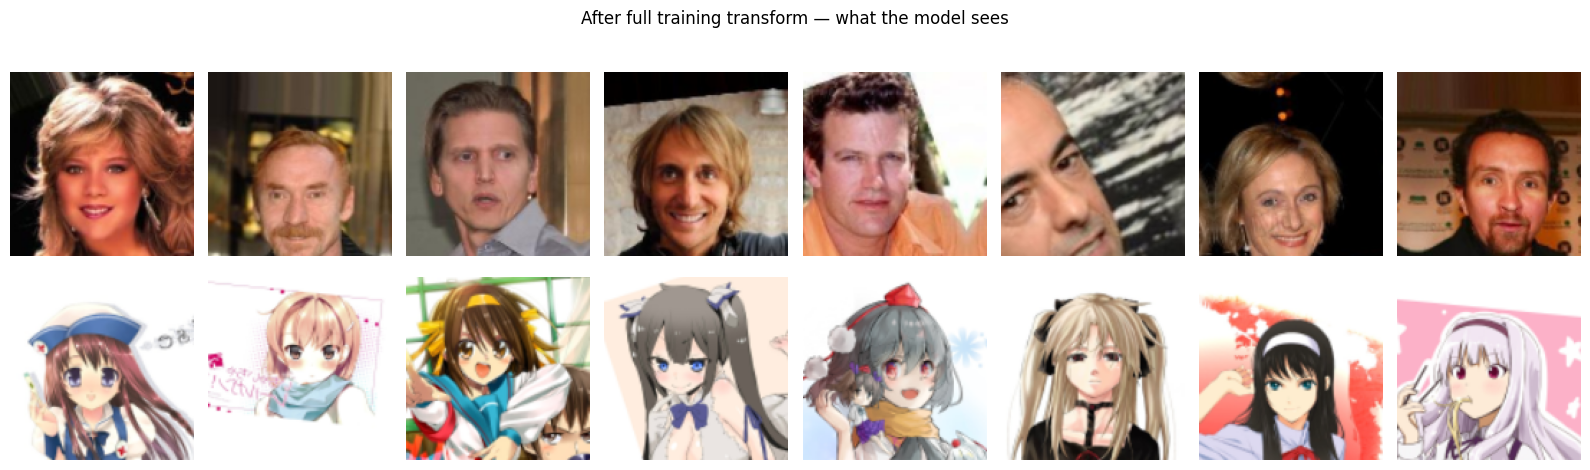

In [7]:
def to_tensor_rgb(img_np: np.ndarray):
    return tensor_to_rgb(transform(Image.fromarray(img_np)))


t_aligned_a = [to_tensor_rgb(img) for img in aligned_a]
t_crops_b = [to_tensor_rgb(img) for img in crops_b]

fig, axes = plt.subplots(2, N_COLS, figsize=(N_COLS * 2, 5))
show_row(t_aligned_a, "A  final\n(+augment)", axes[0])
show_row(t_crops_b, "B  final\n(+augment)", axes[1])

fig.suptitle("After full training transform — what the model sees", fontsize=12)
plt.tight_layout()
plt.show()